In [1]:
# import packages
import copy
import numpy as np
import math
from scipy import integrate
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pickle
import time
from numpy.random import rand
from scipy.optimize import minimize
import warnings


In [2]:
### Wetted perimeter P, Area A, for parabola z=y^2 
def aux_area_perimeter_ay2(h,a):
    
    W = 2*(h/a)**(1/2);
    P = (h/a+4*h**2)**(1/2) + 1/(2*a) * np.arcsinh(2*(a*h)**(1/2)); 
    A = 4/3*h**(3/2)/a**(1/2);

    return W, P, A 

### Wetted perimeter P, Area A, for trapezium
def aux_area_perimeter_trap(h,W,alpha):    
    
    A = 1/2*h*W*(1+alpha);
    P = alpha*W + 2*(h**2+.25*(W**2)*(1-alpha)**2)**(1/2)

    return P, A 



In [3]:
### Solve dh/dx = (S0-Sf)/(1-Fr^2) using Forward Euler. Note that S0 needs to be taken as known! 
### As does the geometry, which appears in P, A and hence Sf and Fr. 
### We have to solve this every optimisation step, since we vary S0 to find the best S0 to fit eta.

def aux_integrate_GVF_FE_trap(S0,alpha,dx,x,N,h_init,n,g,Q,W):

    h=np.zeros(N)
    h=h.reshape(N,1)
    h[0]=h_init
    dhdx=np.zeros(N); Sf=np.zeros(N); Fr2=np.zeros(N);
    A=np.zeros(N); P=np.zeros(N);

    
    # dh/dx = (S0-Sf)/(1-Fr2)
    # Use Forward Euler method (very basic but sufficient method for our problem)
    # dhdx ~ (h[p+1]-h[p])/dx
    for p in range(N-1):
        [P[p],A[p]] = aux_area_perimeter_trap(h[p],W[p],alpha[p])
        Sf[p] = (n**2) * (Q**2) * (P[p]**(4/3))/((A[p]**(10/3)))
        Fr2[p] = (Q**2)*W[p]/(g*(A[p]**3))
        dhdx[p] = (S0[p]-Sf[p])/(1-Fr2[p]) 
        h[p+1] = h[p] + dx*dhdx[p]
    p=N-1
    [P[p],A[p]] = aux_area_perimeter_trap(h[p],W[p],alpha[p])
    
    ### Integrate to get z_b. z_b is the bottom of the river
    ### Where dz_b/dx = -S0. We integrate to get dz_b/dx
    zb = integrate.cumtrapz(-S0.reshape(1,N),x,initial=0)
    zb = np.transpose(zb)
    
    ### Solve for free-surface displacement, eta
    eta = h + zb

    return h, P, A, eta




In [4]:
### This is the objective function, it returns an error vector where  corresponding to the difference
### between the computed eta with the guessed S0, and the eta_data.
### It is not the least-square error: the optimiser computes this for us. We feed the optimiser a vector
### ERR[i] = eta_data[i] - eta[i].
def objective_vector(S0,alpha,dx,x,N,h_init,n,g,Q,W,eta_data):
    #S0=np.array(S0)
    h=np.zeros(N)
    h=h.reshape(N,1)
    h[0]=h_init
    dhdx=np.zeros(N); Sf=np.zeros(N); Fr2=np.zeros(N);
    A=np.zeros(N); P=np.zeros(N);

    for p in range(N-1):
        [P[p],A[p]] = aux_area_perimeter_trap(h[p],W[p],alpha[p])
        Sf[p] = (n**2) * (Q**2) * (P[p]**(4/3))/((A[p]**(10/3)))
        Fr2[p] = (Q**2)*W[p]/(g*(A[p]**3))
        dhdx[p] = (S0[p]-Sf[p])/(1-Fr2[p]) 
        h[p+1] = h[p] + dx*dhdx[p]
  
    
    ### Solve for free-surface displacement, eta
    zb = integrate.cumtrapz(-S0,x,initial=0)
    eta = h.reshape(N) + zb
    
    
    #print("LS_error = " + str(LS))
    return eta_data.reshape(N)-eta









##################################################################################
# Below are old obective functions. They may be useful in the future. 
# 
#################################################################################

def objective(S0,alpha,dx,x,N,h_init,n,g,Q,W,eta_data):

    #S0=np.array(S0)
    h=np.zeros(N)
    h=h.reshape(N,1)
    h[0]=h_init
    dhdx=np.zeros(N); Sf=np.zeros(N); Fr2=np.zeros(N);
    A=np.zeros(N); P=np.zeros(N);

    for p in range(N-1):
        [P[p],A[p]] = aux_area_perimeter_trap(h[p],W[p],alpha[p])
        Sf[p] = (n**2) * (Q**2) * (P[p]**(4/3))/((A[p]**(10/3)))
        Fr2[p] = (Q**2)*W[p]/(g*(A[p]**3))
        dhdx[p] = (S0[p]-Sf[p])/(1-Fr2[p]) 
        h[p+1] = h[p] + dx*dhdx[p]
  
    
    ### Solve for free-surface displacement, eta
    zb = integrate.cumtrapz(-S0,x,initial=0)
    eta = h.reshape(N) + zb
    
    LS = sum((eta_data.reshape(N)-eta)**2)

   # plt.plot(eta); plt.plot(eta_data); plt.show()
    plt.plot(S0)
    
    print("LS_error = " + str(LS))
    return LS



#           W
##############################
#                           #
  #                       #
    #####################
    #     alpha*W
# Objective, taking alpha as the optimisation parameter, and S0 as given.
def objective_alpha(alpha,S0,dx,x,N,h_init,n,g,Q,W,eta_data):

    #S0=np.array(S0)
    alpha_vec=np.ones(N)*alpha
    h=np.zeros(N)
    h=h.reshape(N,1)
    h[0]=h_init
    dhdx=np.zeros(N); Sf=np.zeros(N); Fr2=np.zeros(N);
    A=np.zeros(N); P=np.zeros(N);

    for p in range(N-1):
        [P[p],A[p]] = aux_area_perimeter_trap(h[p],W[p],alpha_vec[p])
        Sf[p] = (n**2) * (Q**2) * (P[p]**(4/3))/((A[p]**(10/3)))
        Fr2[p] = (Q**2)*W[p]/(g*(A[p]**3))
        dhdx[p] = (S0[p]-Sf[p])/(1-Fr2[p]) 
        h[p+1] = h[p] + dx*dhdx[p]
  
    
    ### Solve for free-surface displacement, eta
    zb = integrate.cumtrapz(-S0,x,initial=0)
    eta = h.reshape(N) + zb
    
    LS = sum((eta_data.reshape(N)-eta)**2)

   # plt.plot(eta); plt.plot(eta_data); plt.show()
   
    
    print("LS_error = " + str(LS))
    return LS



In [5]:
# Load "data", which is solution of GVF with random geometry.
with open('random_river_data1.pkl', 'rb') as file:
    [x,dx,N,L,y,Ny,Ly,X,Y,Q,n,g,a,S0,zb,W,P,A,h,dhdx,Sf,Fr2] = pickle.load(file)

# Initial height of river at x=0. Known
h_init=h[0]

# Alpha changes the ration of the trapezium. For now, test different values 
# between 0 and 1. Later, we will try and vary it as a function of x in the 
# optimisation
alpha=.4*np.ones(N)

# Eta is the free-surface profile. It is the LADAR data that we will one day 
# collect from online sources. For know, we take it as coming from a solution of 
# the GVF equations with varying more complicated bathymetry
eta_data = h+zb

# S0 is the bed slope. In the optimisation problem, it is unknown, and being 
# varied to best approximate eta.
S0_data = S0

# zb is the x integral of -S0. It is the bottom of the river. This is useful
# for plotting
zb_data = zb

# S0_initialguess is the our first guess for S0. In this case, we can use the actual S0, but in future it will need 
# to be constructed from Mannings law (see paper by Neal et al for details)
S0_initialguess = S0


In [6]:
from scipy.optimize import least_squares

Beginning optimisation: please be patient, it may take a minute. 
If this fails, it may be that the GVF solver hit critical control (Fr=1), which is a singularity in the equation
In this case, check the initial guess, by running [h, P, A, eta] = aux_integrate_GVF_FE_trap(S0,alpha,dx,x,N,h_init,n,g,Q,W)
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         9.3319e+00                                    1.16e+03    
       1              2         2.3056e-01      9.10e+00       2.99e-03       2.03e+02    
       2              3         1.3833e-04      2.30e-01       6.03e-04       4.38e+00    
       3              4         1.9242e-08      1.38e-04       5.10e-04       3.19e-02    
       4              5         4.3410e-15      1.92e-08       2.54e-05       2.27e-05    
       5              6         1.4786e-25      4.34e-15       9.79e-09       1.69e-10    
`gtol` termination condition is satisfied.
Function evaluat

Text(0, 0.5, 'z')

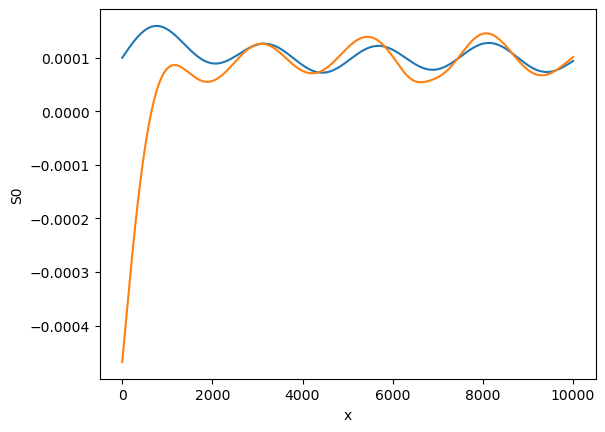

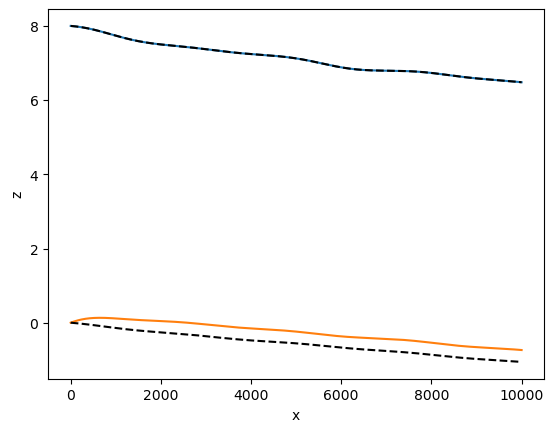

In [7]:
# ----------------------------------------------------------------------- #
# Optimise
# ----------------------------------------------------------------------- #
# Reshape S0 for annoying python reasons to an N- np array
S0_initialguess=S0_initialguess.reshape(N)
##############################################################################

# Params are what we change in the optimisation routine. objective_vector is what is minimised.
# args are the other parameters required for the function 
# objective_vector(params,args) =  objective_vector(S0,alpha,dx,x,N,h_init,n,g,Q,W,eta_data)
params=S0_initialguess
print("Beginning optimisation: please be patient, it may take a minute. ")
print("If this fails, it may be that the GVF solver hit critical control (Fr=1), which is a singularity in the equation")
print("In this case, check the initial guess, by running [h, P, A, eta] = aux_integrate_GVF_FE_trap(S0,alpha,dx,x,N,h_init,n,g,Q,W)")

res2 = least_squares(objective_vector,
                     x0=params,
                     jac='2-point',
                     bounds=(-1, 1), 
                     method='trf', 
                     ftol=1e-08, 
                     xtol=1e-08, 
                     gtol=1e-08,
                  #   x_scale=1.0, 
                     loss='linear', 
                     f_scale=1.0, 
                     diff_step=None, 
                     tr_solver=None, 
                     tr_options={}, 
                     jac_sparsity=None,
                     max_nfev=None,
                     verbose=2, 
                     args=(alpha,dx,x,N,h_init,n,g,Q,W,eta_data),
                     kwargs={})


S0_bestfit = res2.x


# Plot the original S0, and best fit S0
plt.plot(x,S0_initialguess); plt.plot(x,S0_bestfit);
plt.xlabel('x')
plt.ylabel('S0')



# Solve GVF with new S0
[h_bestfit, P_bestfit, A_bestfit, eta_bestfit] =  aux_integrate_GVF_FE_trap(S0_bestfit,alpha,dx,x,N,h_init,n,g,Q,W)
zb_bestfit = integrate.cumtrapz(-S0_bestfit,x,initial=0)

plt.figure()
plt.plot(x,eta_bestfit)
plt.plot(x,zb_bestfit)
plt.plot(x,eta_data,'k--')
plt.plot(x,zb_data,'k--')
plt.xlabel('x')
plt.ylabel('z')

In [6]:
# Plot results
plt.figure()
plt.plot(x, eta_bestfit, label='Best-fit Eta')
plt.plot(x, zb_bestfit, label='Best-fit zb')
plt.plot(x, eta_data, 'k--', label='Observed Eta')
plt.plot(x, zb_data, 'k--', label='Observed zb')
plt.xlabel('x')
plt.ylabel('z')
plt.legend()
plt.show()

NameError: name 'eta_bestfit' is not defined

<Figure size 640x480 with 0 Axes>

In [7]:
# ----------------------------------------------------------------------- #
# Optimise alpha
# ----------------------------------------------------------------------- #
# Not tested: What about if S0 is known, but we vary alpha, as a constant, so that alpha is the same for all x. Does 
# this work? 

S0=S0.reshape(N)
S0_init = S0

res = minimize(objective_alpha, 
               x0=0.4, 
               args=(S0,dx,x,N,h_init,n,g,Q,W,eta_data))
print(alpha)

LS_error = 18.663872031104873
LS_error = 18.66388097000726
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan


/tmp/ipykernel_180/508552965.py:92: RuntimeWarning: invalid value encountered in double_scalars
  Sf[p] = (n**2) * (Q**2) * (P[p]**(4/3))/((A[p]**(10/3)))


LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error =

/tmp/ipykernel_180/508552965.py:92: RuntimeWarning: invalid value encountered in double_scalars
  Sf[p] = (n**2) * (Q**2) * (P[p]**(4/3))/((A[p]**(10/3)))


LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
LS_error = nan
[0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.

/tmp/ipykernel_180/508552965.py:92: RuntimeWarning: invalid value encountered in double_scalars
  Sf[p] = (n**2) * (Q**2) * (P[p]**(4/3))/((A[p]**(10/3)))


In [8]:
# modified with single alpha
def objective_alpha(constant_alpha, S0, dx, x, N, h_init, n, g, Q, W, eta_data):
    #  constant alpha value for all calculations
    alpha_vec = np.full(N, constant_alpha)
    model_predictions = aux_integrate_GVF_FE_trap(S0, alpha_vec, dx, x, N, h_init, n, g, Q, W)[3]
    
    # mean squared error between model predictions and observed data
    error = np.mean((model_predictions - eta_data) ** 2)
    
    return error

initial_constant_alpha_guess = 0.4  

res = minimize(objective_alpha, 
               x0=initial_constant_alpha_guess, 
               args=(S0, dx, x, N, h_init, n, g, Q, W, eta_data))

optimized_constant_alpha = res.x[0]
print("Optimized Constant Alpha:", optimized_constant_alpha)


Optimized Constant Alpha: 0.34531295674281365


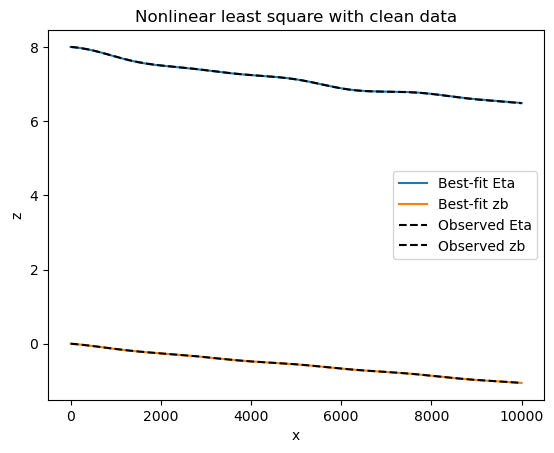

In [9]:
optimized_alpha = 0.3458685530685428 

# array thing
alpha_values = np.full(N, optimized_alpha)

# GVF integration
[h_bestfit, P_bestfit, A_bestfit, eta_bestfit] =  aux_integrate_GVF_FE_trap(S0, alpha_values, dx, x, N, h_init, n, g, Q, W)
zb_bestfit = integrate.cumtrapz(-S0, x, initial=0)

plt.figure()
plt.plot(x,eta_bestfit, label='Best-fit Eta')
plt.plot(x,zb_bestfit, label='Best-fit zb')
plt.plot(x,eta_data,'k--', label='Observed Eta')
plt.plot(x,zb_data,'k--', label='Observed zb')
plt.xlabel('x')
plt.ylabel('z')
plt.title('Nonlinear least square with clean data')
plt.legend()
plt.show()

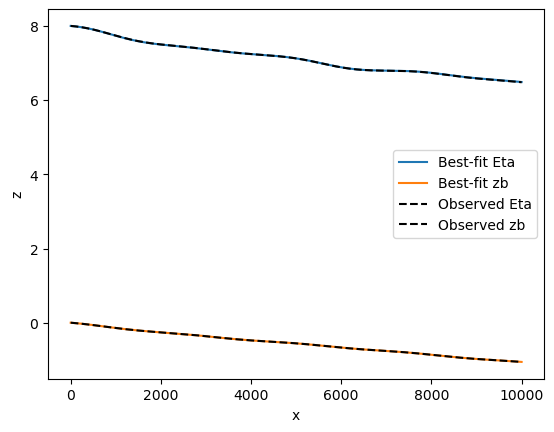

In [10]:
# Plot results
plt.figure()
plt.plot(x, eta_bestfit, label='Best-fit Eta')
plt.plot(x, zb_bestfit, label='Best-fit zb')
plt.plot(x, eta_data, 'k--', label='Observed Eta')
plt.plot(x, zb_data, 'k--', label='Observed zb')
plt.xlabel('x')
plt.ylabel('z')
plt.legend()
plt.show()

In [12]:
# Calculate residual sum of squares
residual_sum_of_squares_nls = np.sum((eta_data - eta_bestfit) ** 2)

# Calculate number of parameters
n_parameters_nls = len(S0_bestfit)

# Calculate AIC
aic_nls = 2 * n_parameters_nls + N * np.log(residual_sum_of_squares_nls / N)

print("AIC for nonlinear least squares method:", aic_nls)


AIC for nonlinear least squares method: -10700.222150843038


/tmp/ipykernel_159/1185901072.py:19: RuntimeWarning: invalid value encountered in double_scalars
  Sf[p] = (n**2) * (Q**2) * (P[p]**(4/3))/((A[p]**(10/3)))


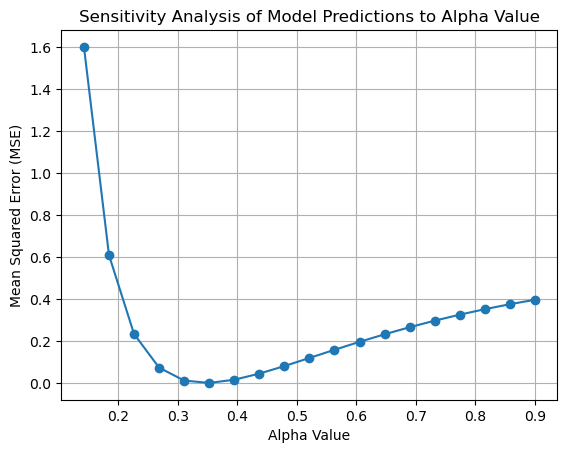

In [12]:
# range of alpha values to explore
alpha_range = np.linspace(0.1, 0.9, 20)  
sensitivity_results = []

# Iterate over each alpha value and re-run the model
for alpha_value in alpha_range:
    # Use the current alpha value in the modeling process
    alpha_values = np.full(N, alpha_value)
    [h_bestfit, P_bestfit, A_bestfit, eta_bestfit] =  aux_integrate_GVF_FE_trap(S0, alpha_values, dx, x, N, h_init, n, g, Q, W)
    
    mse = np.mean((eta_bestfit - eta_data) ** 2)
    sensitivity_results.append(mse)

plt.plot(alpha_range, sensitivity_results, marker='o')
plt.xlabel('Alpha Value')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Sensitivity Analysis of Model Predictions to Alpha Value')
plt.grid(True)
plt.show()

In [11]:
import copy
def objective_alpha_vector(alpha, S0, dx, x, N, h_init, n, g, Q, W, eta_data):
    h, P, A, eta = aux_integrate_GVF_FE_trap(S0, alpha, dx, x, N, h_init, n, g, Q, W)
    zb = integrate.cumtrapz(-S0, x, initial=0)
    error = np.mean((eta - eta_data) ** 2)
    return error

with open('random_river_data.pkl', 'rb') as file:
    [x,dx,N,L,y,Ny,Ly,X,Y,Q,n,g,a,S0,zb,W,P,A,h,dhdx,Sf,Fr2] = pickle.load(file)

# Initial height of river at x=0 (known)
h_init = h[0]

# Alpha changes the ratio of the trapezium. For now, testing different values between 0 and 1.
alpha_initial_guess = np.full(N, 0.4)  # Initial guess for alpha

# Bounds for alpha (assuming alpha should be between 0 and 1)
alpha_bounds = (0, 1)

# Reshape S0 for annoying python reasons to an N- np array
S0_initialguess = S0.reshape(N)

# Optimize alpha while keeping S0 fixed
res = least_squares(objective_alpha_vector,
                    x0=alpha_initial_guess,
                    bounds=alpha_bounds,
                    method='trf',
                    ftol=1e-08,
                    xtol=1e-08,
                    gtol=1e-08,
                    max_nfev=100,
                    loss='linear',
                    f_scale=1.0,
                    verbose=2,
                    args=(S0_initialguess, dx, x, N, h_init, n, g, Q, W, eta_data))

optimized_alpha_vector = res.x

# Plotting
plt.plot(x, optimized_alpha_vector)
plt.xlabel('x')
plt.ylabel('Optimized Alpha')
plt.show()

NameError: name 'least_squares' is not defined

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.7911e+00                                    7.29e+02    
       1              2         7.7400e-02      4.71e+00       2.99e-03       9.79e+01    
       2              3         2.3680e-05      7.74e-02       6.06e-04       1.48e+00    
       3              4         7.2502e-10      2.37e-05       3.13e-04       6.17e-03    
       4              5         3.4554e-18      7.25e-10       4.78e-06       5.12e-07    
       5              6         2.4601e-26      3.46e-18       3.04e-10       5.16e-11    
`gtol` termination condition is satisfied.
Function evaluations 6, initial cost 4.7911e+00, final cost 2.4601e-26, first-order optimality 5.16e-11.


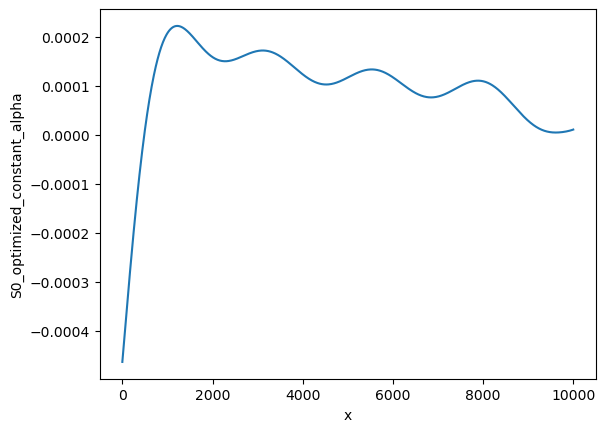

In [11]:
def objective_constant_alpha(S0, alpha, dx, x, N, h_init, n, g, Q, W, eta_data):
    # Use a constant alpha array
    alpha_array = np.ones(N) * alpha
    
    # Compute the discrepancy using previously defined functions
    return objective_vector(S0, alpha_array, dx, x, N, h_init, n, g, Q, W, eta_data)
# Alpha remains constant
alpha_constant = 0.4  # you can adjust this value as needed

# Optimize for varying S0 with constant alpha
res_s0_varying = least_squares(
    objective_vector,
    x0=S0_initialguess,
    bounds=(-1, 1),
    method='trf', 
    args=(np.ones(N) * alpha_constant, dx, x, N, h_init, n, g, Q, W, eta_data),
    verbose=2
)

S0_optimized_constant_alpha = res_s0_varying.x
# Plotting
plt.plot(x, S0_optimized_constant_alpha)
plt.xlabel('x')
plt.ylabel('S0_optimized_constant_alpha')
plt.show()

## optimization using Nelder-Mead method

In [24]:
## https://docs.scipy.org/doc/scipy/reference/optimize.minimize-neldermead.html

In [ ]:
h_init = h[0]
alpha = np.full(N, 0.4)  
eta_data = h + zb
S0_data = S0
S0_initialguess = S0.reshape(N)

# objective function (negative log-likelihood)
def negative_log_likelihood(S0):
    h = np.zeros(N)
    h[0] = h_init
    dhdx = np.zeros(N)
    Sf = np.zeros(N)
    Fr2 = np.zeros(N)
    A = np.zeros(N)
    P = np.zeros(N)
    
    for p in range(N-1):
        [P[p], A[p]] = aux_area_perimeter_trap(h[p], W[p], alpha[p])
        Sf[p] = (n**2) * (Q**2) * (P[p]**(4/3)) / ((A[p]**(10/3)))
        Fr2[p] = (Q**2) * W[p] / (g * (A[p]**3))
        dhdx[p] = (S0[p] - Sf[p]) / (1 - Fr2[p])
        h[p+1] = h[p] + dx * dhdx[p]
    
    # Calculate negative log-likelihood
    zb = integrate.cumtrapz(-S0, x, initial=0)
    eta = h + zb
    error = eta_data - eta
    likelihood = np.sum(error ** 2)  # Sum of squared errors
    return likelihood

# optimization using Nelder-Mead method
res = minimize(negative_log_likelihood, S0_initialguess, method='Nelder-Mead')

# Extract best-fit parameters
S0_bestfit = res.x

# Calculate best-fit values of h and eta
h_bestfit = np.zeros(N)
h_bestfit[0] = h_init
dhdx_bestfit = np.zeros(N)
Sf_bestfit = np.zeros(N)
Fr2_bestfit = np.zeros(N)
A_bestfit = np.zeros(N)
P_bestfit = np.zeros(N)

for p in range(N-1):
    [P_bestfit[p], A_bestfit[p]] = aux_area_perimeter_trap(h_bestfit[p], W[p], alpha[p])
    Sf_bestfit[p] = (n**2) * (Q**2) * (P_bestfit[p]**(4/3)) / ((A_bestfit[p]**(10/3)))
    Fr2_bestfit[p] = (Q**2) * W[p] / (g * (A_bestfit[p]**3))
    dhdx_bestfit[p] = (S0_bestfit[p] - Sf_bestfit[p]) / (1 - Fr2_bestfit[p])
    h_bestfit[p+1] = h_bestfit[p] + dx * dhdx_bestfit[p]

zb_bestfit = integrate.cumtrapz(-S0_bestfit, x, initial=0)

# Plot results
plt.figure()
plt.plot(x, h_bestfit + zb_bestfit, label='Best-fit Eta')
plt.plot(x, zb_bestfit, label='Best-fit zb')
plt.plot(x, eta_data, 'k--', label='Observed Eta')
plt.plot(x, zb_data, 'k--', label='Observed zb')
plt.xlabel('x')
plt.ylabel('z')
plt.title('Nelder Mead using clean data')
plt.legend()
plt.show()


In [14]:
res

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9071435149206512
             x: [ 1.000e-04  1.039e-04 ...  2.331e-05  2.516e-05]
           nit: 1
          nfev: 1001
 final_simplex: (array([[ 1.000e-04,  1.039e-04, ...,  2.331e-05,
                         2.516e-05],
                       [ 1.000e-04,  1.039e-04, ...,  2.331e-05,
                         2.516e-05],
                       ...,
                       [ 1.000e-04,  1.039e-04, ...,  2.331e-05,
                         2.516e-05],
                       [ 1.000e-04,  1.039e-04, ...,  2.331e-05,
                         2.516e-05]]), array([ 9.071e-01,  9.071e-01, ...,  9.072e-01,  9.072e-01]))

In [26]:
# function to compute model predictions for given S0 and alpha
def model_predictions(S0, alpha, dx, x, N, h_init, n, g, Q, W):
    alpha_vec = np.full(N, alpha)
    _, _, _, eta = aux_integrate_GVF_FE_trap(S0, alpha_vec, dx, x, N, h_init, n, g, Q, W)
    return eta

# objective function to minimize (mean squared error between model predictions and observed data)
def objective_alpha(constant_alpha, S0, dx, x, N, h_init, n, g, Q, W, eta_data):
    model_eta = model_predictions(S0, constant_alpha, dx, x, N, h_init, n, g, Q, W)
    error = np.mean((model_eta - eta_data) ** 2)
    return error

# optimization using Nelder-Mead method
initial_constant_alpha_guess = 0.4
res = minimize(objective_alpha, 
               x0=initial_constant_alpha_guess, 
               args=(S0_initialguess, dx, x, N, h_init, n, g, Q, W, eta_data),
               method='Nelder-Mead')

# optimized constant alpha
optimized_constant_alpha = res.x[0]
print("Optimized Constant Alpha:", optimized_constant_alpha)


Optimized Constant Alpha: 0.3458593750000001


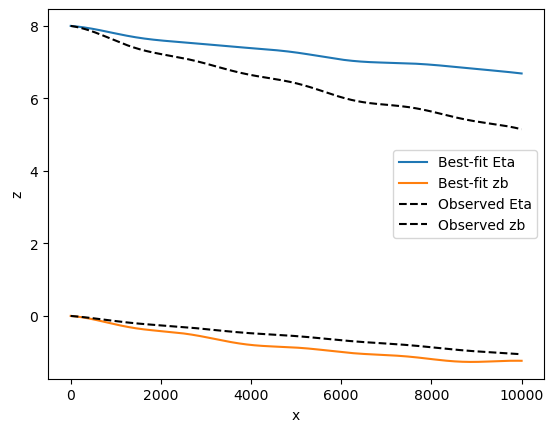

In [13]:
h_init = h[0]
alpha = 0.3458593750000001  # Optimized constant alpha value
eta_data = h + zb
S0_data = S0
S0_initialguess = S0.reshape(N)

# function to compute model predictions for given S0 and alpha
def model_predictions(S0, alpha, dx, x, N, h_init, n, g, Q, W):
    alpha_vec = np.full(N, alpha)
    _, _, _, eta = aux_integrate_GVF_FE_trap(S0, alpha_vec, dx, x, N, h_init, n, g, Q, W)
    return eta

# objective function to minimize (mean squared error between model predictions and observed data)
def objective(S0, alpha, dx, x, N, h_init, n, g, Q, W, eta_data):
    model_eta = model_predictions(S0, alpha, dx, x, N, h_init, n, g, Q, W)
    error = np.mean((model_eta - eta_data) ** 2)
    return error

# optimization using Nelder-Mead method
res = minimize(objective, 
               x0=S0_initialguess, 
               args=(alpha, dx, x, N, h_init, n, g, Q, W, eta_data),
               method='Nelder-Mead')

# Extract best-fit parameters
S0_bestfit = res.x

# Calculate best-fit values of h and eta
h_bestfit = np.zeros(N)
h_bestfit[0] = h_init
dhdx_bestfit = np.zeros(N)
Sf_bestfit = np.zeros(N)
Fr2_bestfit = np.zeros(N)
A_bestfit = np.zeros(N)
P_bestfit = np.zeros(N)

for p in range(N-1):
    [P_bestfit[p], A_bestfit[p]] = aux_area_perimeter_trap(h_bestfit[p], W[p], alpha)
    Sf_bestfit[p] = (n**2) * (Q**2) * (P_bestfit[p]**(4/3)) / ((A_bestfit[p]**(10/3)))
    Fr2_bestfit[p] = (Q**2) * W[p] / (g * (A_bestfit[p]**3))
    dhdx_bestfit[p] = (S0_bestfit[p] - Sf_bestfit[p]) / (1 - Fr2_bestfit[p])
    h_bestfit[p+1] = h_bestfit[p] + dx * dhdx_bestfit[p]

zb_bestfit = integrate.cumtrapz(-S0_bestfit, x, initial=0)

# Plot results
plt.figure()
plt.plot(x, h_bestfit + zb_bestfit, label='Best-fit Eta')
plt.plot(x, zb_bestfit, label='Best-fit zb')
plt.plot(x, eta_data, 'k--', label='Observed Eta')
plt.plot(x, zb_data, 'k--', label='Observed zb')
plt.xlabel('x')
plt.ylabel('z')
plt.legend()
plt.show()


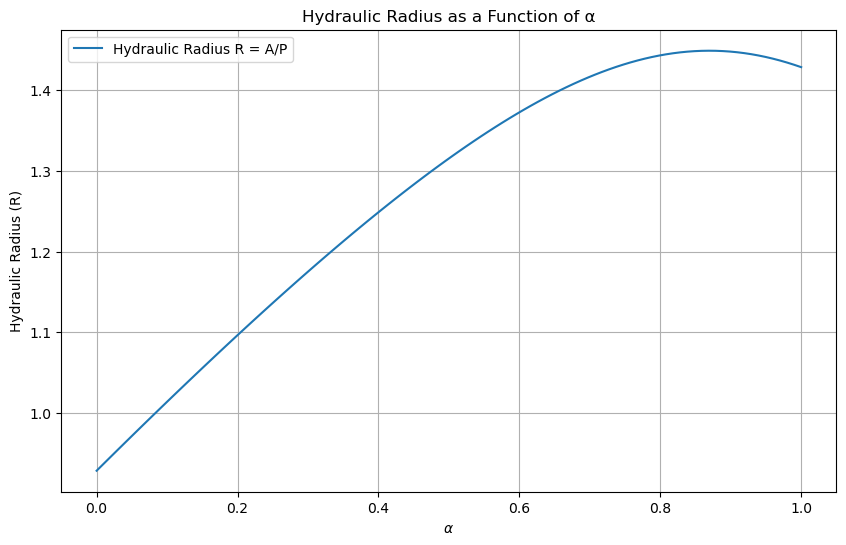

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def aux_area_perimeter_trap(h, W, alpha):
    # Area of the trapezoid
    A = 0.5 * h * W * (1 + alpha)
    # Wetted perimeter of the trapezoid
    P = alpha * W + 2 * np.sqrt(h**2 + 0.25 * (W**2) * (1 - alpha)**2)
    return A, P

# Parameters
Q = 10  # Discharge (arbitrary constant for this example)
n = 0.03  # Manning's roughness coefficient (arbitrary constant)
g = 9.81  # Gravitational acceleration
S0 = 0.001  # Bed slope (arbitrary constant)
W = 10  # Channel width (arbitrary constant)
h = 2  # Channel depth (arbitrary constant)

alphas = np.linspace(0, 1, 100)  # 100 values from 0 to 1
R_values = []

for alpha in alphas:
    A, P = aux_area_perimeter_trap(h, W, alpha)
    R = A / P
    R_values.append(R)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(alphas, R_values, label="Hydraulic Radius R = A/P")
plt.xlabel(r"$\alpha$")
plt.ylabel("Hydraulic Radius (R)")
plt.title("Hydraulic Radius as a Function of α")
plt.legend()
plt.grid()
plt.show()


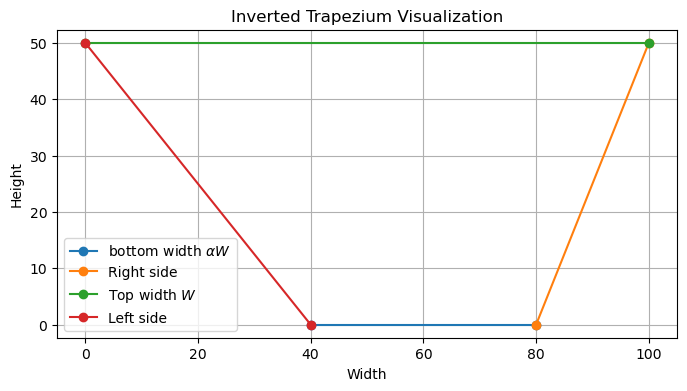

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Constants
W = 100  # width of the top
h = 50   # height of the trapezium
theta_prime = 10  # the offset from the vertical, previously delta
alpha = 0.4  # proportion of the bottom width relative to the top width

# Calculate the bottom width which is now at the top
bottom_width = alpha * W

# Coordinates of the trapezium, flipped vertically
# Top left and right
x1, y1 = (W - bottom_width) / 2 + theta_prime, 0
x2, y2 = (W + bottom_width) / 2 + theta_prime, 0

# Bottom left and right
x3, y3 = 0, h
x4, y4 = W, h

# Draw the trapezium
plt.figure(figsize=(8, 4))
plt.plot([x1, x2], [y1, y2], label='bottom width $\\alpha W$', marker='o')  
plt.plot([x2, x4], [y2, y4], label='Right side', marker='o')
plt.plot([x4, x3], [y4, y3], label='Top width $W$', marker='o')  
plt.plot([x3, x1], [y3, y1], label='Left side', marker='o')

# Set equal scaling and labels
plt.axis('equal')
plt.grid(True)
plt.title('Inverted Trapezium Visualization')
plt.xlabel('Width')
plt.ylabel('Height')
plt.legend()
plt.show()
